# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [1]:
! git clone https://github.com/SafaaMahbub/undergrad_ml_assignments
%run ./undergrad_ml_assignments/get_data.py

Cloning into 'undergrad_ml_assignments'...
remote: Enumerating objects: 283, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 283 (delta 7), reused 4 (delta 4), pack-reused 274 (from 2)
Receiving objects: 100% (283/283), 17.23 MiB | 15.08 MiB/s, done.
Resolving deltas: 100% (132/132), done.
Download complete
Extracting data files...
Data extracted


In [8]:
import pandas as pd

df = pd.read_csv("/content/undergrad_ml_assignments/data/data.csv", sep=';')
df.head()

columns = ['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment','Curricular units 1st sem (approved)', 'Target']
df = df[columns]
df.head()

#dropping any missing data
df = df.dropna()

df['DropoutID'] = (df['Target']=='Dropout').astype(int)

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = df[['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']]
y= df['DropoutID']


reg = LogisticRegression(penalty=None,
                         max_iter=5000)
reg.fit(X, y)

pd.DataFrame({'Variable': X.columns, 'Coefficient': reg.coef_[0]})

,Variable,Coefficient
0,Debtor,0.527137
1,Tuition fees up to date,-2.605617
2,Scholarship holder,-1.242299
3,Age at enrollment,0.049841


Debtors and Age of enrollment have hugher dropout probability since both of them have positive coefficients in the logistic regression model. THis means elder students are more likely to drop out.Tuition fees up to dae and scholarship holders are less likely to dropout since they both hold negative coefficients. It cleatly reduces the droput risk.

In [10]:
df['predict_dropout'] = reg.predict_proba(X)[:,1]
df.head()

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target,DropoutID,predict_dropout
0,0,1,0,20,0,Dropout,1,0.254740
1,0,0,0,19,6,Graduate,0,0.814918
2,0,0,0,19,0,Dropout,1,0.814918
3,0,1,0,20,6,Graduate,0,0.254740
4,0,1,0,45,5,Graduate,0,0.543026


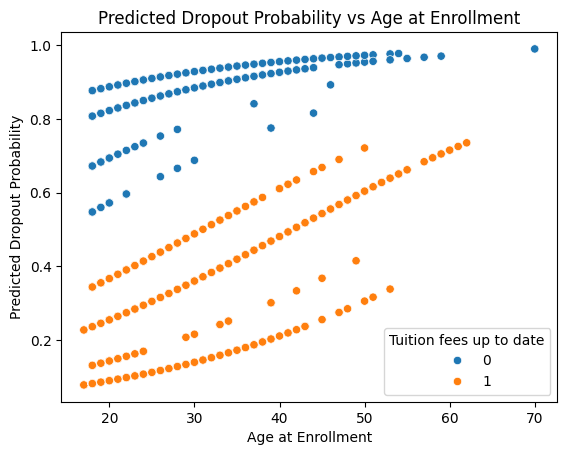

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='Age at enrollment', y='predict_dropout', hue='Tuition fees up to date', data=df)

plt.ylabel("Predicted Dropout Probability")
plt.xlabel("Age at Enrollment")
plt.title("Predicted Dropout Probability vs Age at Enrollment")
plt.show()

Students without tutiom up to date have higher dropout risk.At all ages is the up to date tution reducing the predicted droput

In [14]:
import numpy as np
pred = reg.predict(X)
tab = pd.crosstab(y, pred)
print(tab)

acc = np.trace(tab)/len(y)
print(f"Accuracy: {acc}")


col_0         0    1
DropoutID           
0          2841  162
1           891  530
Accuracy: 0.7619801084990958


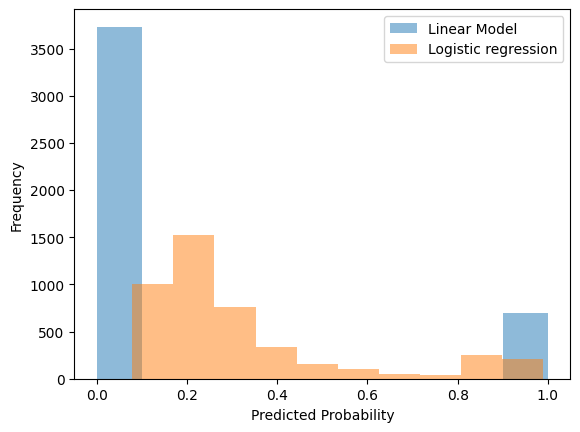

In [15]:
lin = LogisticRegression(penalty=None,
                         max_iter=5000)
lin.fit(X, y)
y_lin = lin.predict(X)

y_reg = reg.predict_proba(X)[:,1]


plt.hist(y_lin, alpha = 0.5, label='Linear Model')
plt.hist(y_reg, alpha = 0.5, label='Logistic regression')
plt.ylabel('Frequency')
plt.xlabel('Predicted Probability')
plt.legend()
plt.show()



the linerat model produces values that are near 0 and 1 but not in the middle. In contrast, the logistic regression produces scaled probabilities between 0 and 1.

I think students that are elder and do not have up to daye tuition have a higher likelihood to dropout. I believe scholarship expansion or need-based aid should me moreflexible.

In [16]:
MultiX = df[['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']]
Multiy = df['Target']

multiReg = LogisticRegression(penalty=None,
                         max_iter=5000)
multiReg.fit(MultiX, Multiy)

Y_pred = multiReg.predict(MultiX)
tab = pd.crosstab(Multiy, Y_pred)
print(tab)

col_0     Dropout  Graduate
Target                     
Dropout      1054       367
Enrolled      280       514
Graduate      146      2063


this shows that the model performs best on GRaduate class correclty classifying 2063 obseervations. The dropout are well predicted.

In [17]:
probs = multiReg.predict_proba(MultiX)
print(probs)

[[0.68055966 0.21048622 0.10895412]
 [0.70661484 0.14549358 0.14789159]
 [0.95434321 0.04034074 0.00531605]
 ...
 [0.07158141 0.14040518 0.78801341]
 [0.18369109 0.21255128 0.60375763]
 [0.11734625 0.17678626 0.70586749]]


**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?